In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [27]:
def getCSV(csv):
    dfl = pd.read_csv(csv)
    dfl = dfl[dfl['County']!="Ireland"]
    dfl['County'] = dfl['County'].str.upper()
    dfl['County'] = dfl['County'].apply(lambda x: x[4:])
    
    return dfl
df = getCSV(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\DrivingPassRateCounty.csv')
print(df)
print(list(set(df['Statistic Label'])))

                                Statistic Label         Month   County  \
18                      Driving Tests Delivered  2021 January    CLARE   
19                      Driving Tests Delivered  2021 January    CLARE   
20                      Driving Tests Delivered  2021 January    CLARE   
21                      Driving Tests Delivered  2021 January    CLARE   
22                      Driving Tests Delivered  2021 January    CLARE   
...                                         ...           ...      ...   
104971  Driving Tests Not Conducted / Abandoned     2025 June  WEXFORD   
104972  Driving Tests Not Conducted / Abandoned     2025 June  WEXFORD   
104973  Driving Tests Not Conducted / Abandoned     2025 June  WEXFORD   
104974  Driving Tests Not Conducted / Abandoned     2025 June  WEXFORD   
104975  Driving Tests Not Conducted / Abandoned     2025 June  WEXFORD   

                        Driving Test Categories    UNIT  VALUE  
18                          All Test Categorie

In [28]:
ireland_shapefile = gpd.read_file(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\Ireland_Counties\Counties___Ungen_2019.shp')

In [75]:
label = 'Driving Test Pass Rate'
category = 'Category B (Car or light van)'
month = '2025 January' 
filtered_df = df[(df['Statistic Label']==label)&(df['Driving Test Categories']==category)&(df['Month']==month)]

In [76]:
merged_data = ireland_shapefile.merge(filtered_df, how='left', left_on='ENGLISH', right_on='County')

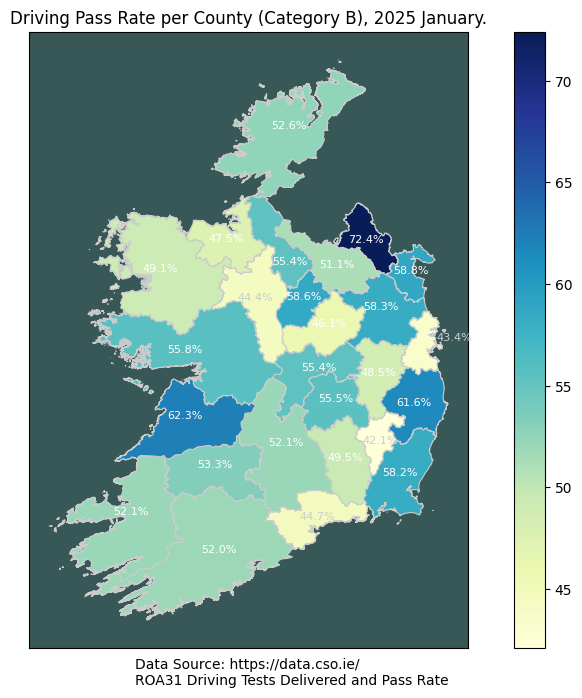

In [77]:
fig, ax = plt.subplots(1,1, figsize=(12,8))

#merged_data['scaled_value'] = np.log1p(merged_data['VALUE'])

merged_data.plot(column='VALUE', cmap='YlGnBu', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

font_size = 8

for idx,row in merged_data.iterrows():
        change = str(row['VALUE'])+"%"
        if row['VALUE'] < 46:
            text_color = "#CCC"
        else:
            text_color = "#FFF"
        if row['ENGLISH'] == "DUBLIN":
            plt.annotate(text=str(change), 
                            xy=(row['CENTROID_X']+25000, row['CENTROID_Y']+2000),  # Assuming you have a 'centroid' column with Point geometries
                            color=text_color, 
                            fontsize=font_size+.2, 
                            ha='center')
        elif row['ENGLISH'] == "OFFALY":
            plt.annotate(text=str(change), 
                            xy=(row['CENTROID_X'], row['CENTROID_Y']+9000),  # Assuming you have a 'centroid' column with Point geometries
                            color=text_color, 
                            fontsize=font_size, 
                            ha='center')
        elif row['ENGLISH'] == "CORK":
            plt.annotate(text=str(change), 
                            xy=(row['CENTROID_X']+24000, row['CENTROID_Y']),  # Assuming you have a 'centroid' column with Point geometries
                            color=text_color, 
                            fontsize=font_size, 
                            ha='center')
        elif row['ENGLISH'] == "MONAGHAN":
            plt.annotate(text=str(change), 
                            xy=(row['CENTROID_X'], row['CENTROID_Y']-3000),  # Assuming you have a 'centroid' column with Point geometries
                            color=text_color, 
                            fontsize=font_size, 
                            ha='center')
        elif row['ENGLISH'] == "WESTMEATH":
            plt.annotate(text=str(change), 
                            xy=(row['CENTROID_X']+4000, row['CENTROID_Y']-3000),  # Assuming you have a 'centroid' column with Point geometries
                            color=text_color, 
                            fontsize=font_size, 
                            ha='center')
        elif row['ENGLISH'] == "CAVAN":
            plt.annotate(text=str(change), 
                            xy=(row['CENTROID_X']+7000, row['CENTROID_Y']-8500),  # Assuming you have a 'centroid' column with Point geometries
                            color=text_color, 
                            fontsize=font_size, 
                            ha='center')
        elif row['ENGLISH'] == "SLIGO":
            plt.annotate(text=str(change), 
                            xy=(row['CENTROID_X'], row['CENTROID_Y']-5000),  # Assuming you have a 'centroid' column with Point geometries
                            color=text_color, 
                            fontsize=font_size, 
                            ha='center')
        elif row['ENGLISH'] == "ROSCOMMON":
            plt.annotate(text=str(change), 
                            xy=(row['CENTROID_X']+4000, row['CENTROID_Y']+3000),  # Assuming you have a 'centroid' column with Point geometries
                            color=text_color, 
                            fontsize=font_size, 
                            ha='center')
        elif row['ENGLISH'] == "LEITRIM":
            plt.annotate(text=str(change), 
                            xy=(row['CENTROID_X']+9000, row['CENTROID_Y']-18000),  # Assuming you have a 'centroid' column with Point geometries
                            color=text_color, 
                            fontsize=font_size, 
                            ha='center')
        elif row['ENGLISH'] == "KERRY":
            plt.annotate(text=str(change), 
                            xy=(row['CENTROID_X']+12000, row['CENTROID_Y']+3000),  # Assuming you have a 'centroid' column with Point geometries
                            color=text_color, 
                            fontsize=font_size, 
                            ha='center')
        elif row['ENGLISH'] == "KILDARE":
            plt.annotate(text=str(change), 
                            xy=(row['CENTROID_X'], row['CENTROID_Y']+3000),  # Assuming you have a 'centroid' column with Point geometries
                            color=text_color, 
                            fontsize=font_size, 
                            ha='center')
        elif row['ENGLISH'] == "KILKENNY":
            plt.annotate(text=str(change), 
                            xy=(row['CENTROID_X']+4500, row['CENTROID_Y']),  # Assuming you have a 'centroid' column with Point geometries
                            color=text_color, 
                            fontsize=font_size, 
                            ha='center')
        elif row['ENGLISH'] == "WATERFORD":
            plt.annotate(text=str(change), 
                            xy=(row['CENTROID_X'], row['CENTROID_Y']),  # Assuming you have a 'centroid' column with Point geometries
                            color=text_color, 
                            fontsize=font_size, 
                            ha='center')
        else:
            plt.annotate(text=str(change), 
                            xy=(row['CENTROID_X'], row['CENTROID_Y']),  # Assuming you have a 'centroid' column with Point geometries
                            color=text_color, 
                            fontsize=font_size, 
                            ha='center')  # Adjust ha and va as needed

title_string = "Driving Pass Rate per County (Category B), "+month+"."
ax.set_title(title_string)

ax.set_facecolor('#385757') 
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

plt.text(0.24, -0.06, "Data Source: https://data.cso.ie/\nROA31 Driving Tests Delivered and Pass Rate ", ha='left', transform=ax.transAxes)

plt.savefig(month+'-DrivingTest'+label+'.png')

plt.show()